# Processing Notebook: Fluid Propagating Through an Infinite Fracture
1. Importing data as gprMax objects
2. Converting to gprData objects
3. Processing using gdp repository
    - SVD / Robust PCA
    - Horizontal filter
    - Gain
    - FK filtering
4. Converting to ImpDar object
5. Running migration in Impdar using Cython
    - Defining velocity model
    - Kirchhoff migration
    - Gazdag migration
6. Final visualisation and comparison with input model

In [1]:
import gdp
from gdp import data_io, DATA_DIR
from gdp.core import GPRData
from gdp.data_io import gprdata_to_impdar
from pathlib import Path
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import warnings
warnings.filterwarnings('ignore')
from impdar.lib import load
import numpy as np
import matplotlib.pyplot as plt
from impdar.lib.migrationlib.mig_python import getVelocityProfile
from impdar.lib.migrationlib import mig_python
from pathlib import Path
import copy
%matplotlib inline

# 1. Importing data as gprMax objects

In [44]:
# import helper functions
from helper_functions import rpca_ialm, kirchhoff_migration

# import numPy files
receiver_positions = np.load('Experiment_9/infinite_fracture_receiver_positions.npy')
time_axis          = np.load('Experiment_9/infinite_fracture_time_axis.npy')
extent             = np.load('Experiment_9/infinite_fracture_extent.npy')

# Define depth samples and mean velocity
depth_samples = np.linspace(0.0, 0.5, 1697)  # Depth samples from 0 to 0.5 m with 2 mm interval
mean_velocity = (3e8 / np.sqrt(6))  # Mean velocity in m/s

output_infinite_fracture_background = np.load('Experiment_9/infinite_fracture_background.npy')
output_infinite_fracture_baseline   = np.load('Experiment_9/infinite_fracture_baseline.npy')
output_infinite_fracture_process_1  = np.load('Experiment_9/infinite_fracture_process_1.npy')
output_infinite_fracture_process_2  = np.load('Experiment_9/infinite_fracture_process_2.npy')
output_infinite_fracture_process_3  = np.load('Experiment_9/infinite_fracture_process_3.npy')

diff_1 = np.load('Experiment_9/infinite_fracture_diff_1.npy')
diff_2 = np.load('Experiment_9/infinite_fracture_diff_2.npy')
diff_3 = np.load('Experiment_9/infinite_fracture_diff_3.npy')

diff_1_scaled = np.load('Experiment_9/infinite_fracture_diff_1_scaled.npy')
diff_2_scaled = np.load('Experiment_9/infinite_fracture_diff_2_scaled.npy')
diff_3_scaled = np.load('Experiment_9/infinite_fracture_diff_3_scaled.npy')

# 2. Converting to gprData object

In [45]:
infinite_fracture_background_data = r'Experiment_9\infinite_fracture_background_merged.out'
component = 'Ez'

# load gprMax object for background data for metadata
background_gprMax_object = data_io.load_gprmax(infinite_fracture_background_data, rx=1, component=component, return_object=True)

# create GPRData objects for raw data
background_GPRData_object = GPRData(output_infinite_fracture_background, background_gprMax_object.info)
baseline_GPRData_object   = GPRData(output_infinite_fracture_baseline  , background_gprMax_object.info)
process_1_GPRData_object  = GPRData(output_infinite_fracture_process_1 , background_gprMax_object.info)
process_2_GPRData_object  = GPRData(output_infinite_fracture_process_2 , background_gprMax_object.info)
process_3_GPRData_object  = GPRData(output_infinite_fracture_process_3 , background_gprMax_object.info)

# create GPRData objects for differences
diff_1_GPRData_object = GPRData(diff_1, background_gprMax_object.info)
diff_2_GPRData_object = GPRData(diff_2, background_gprMax_object.info)
diff_3_GPRData_object = GPRData(diff_3, background_gprMax_object.info)

# 3. Processing using geodataprocessing repository

SVD on raw data to remove the direct wave

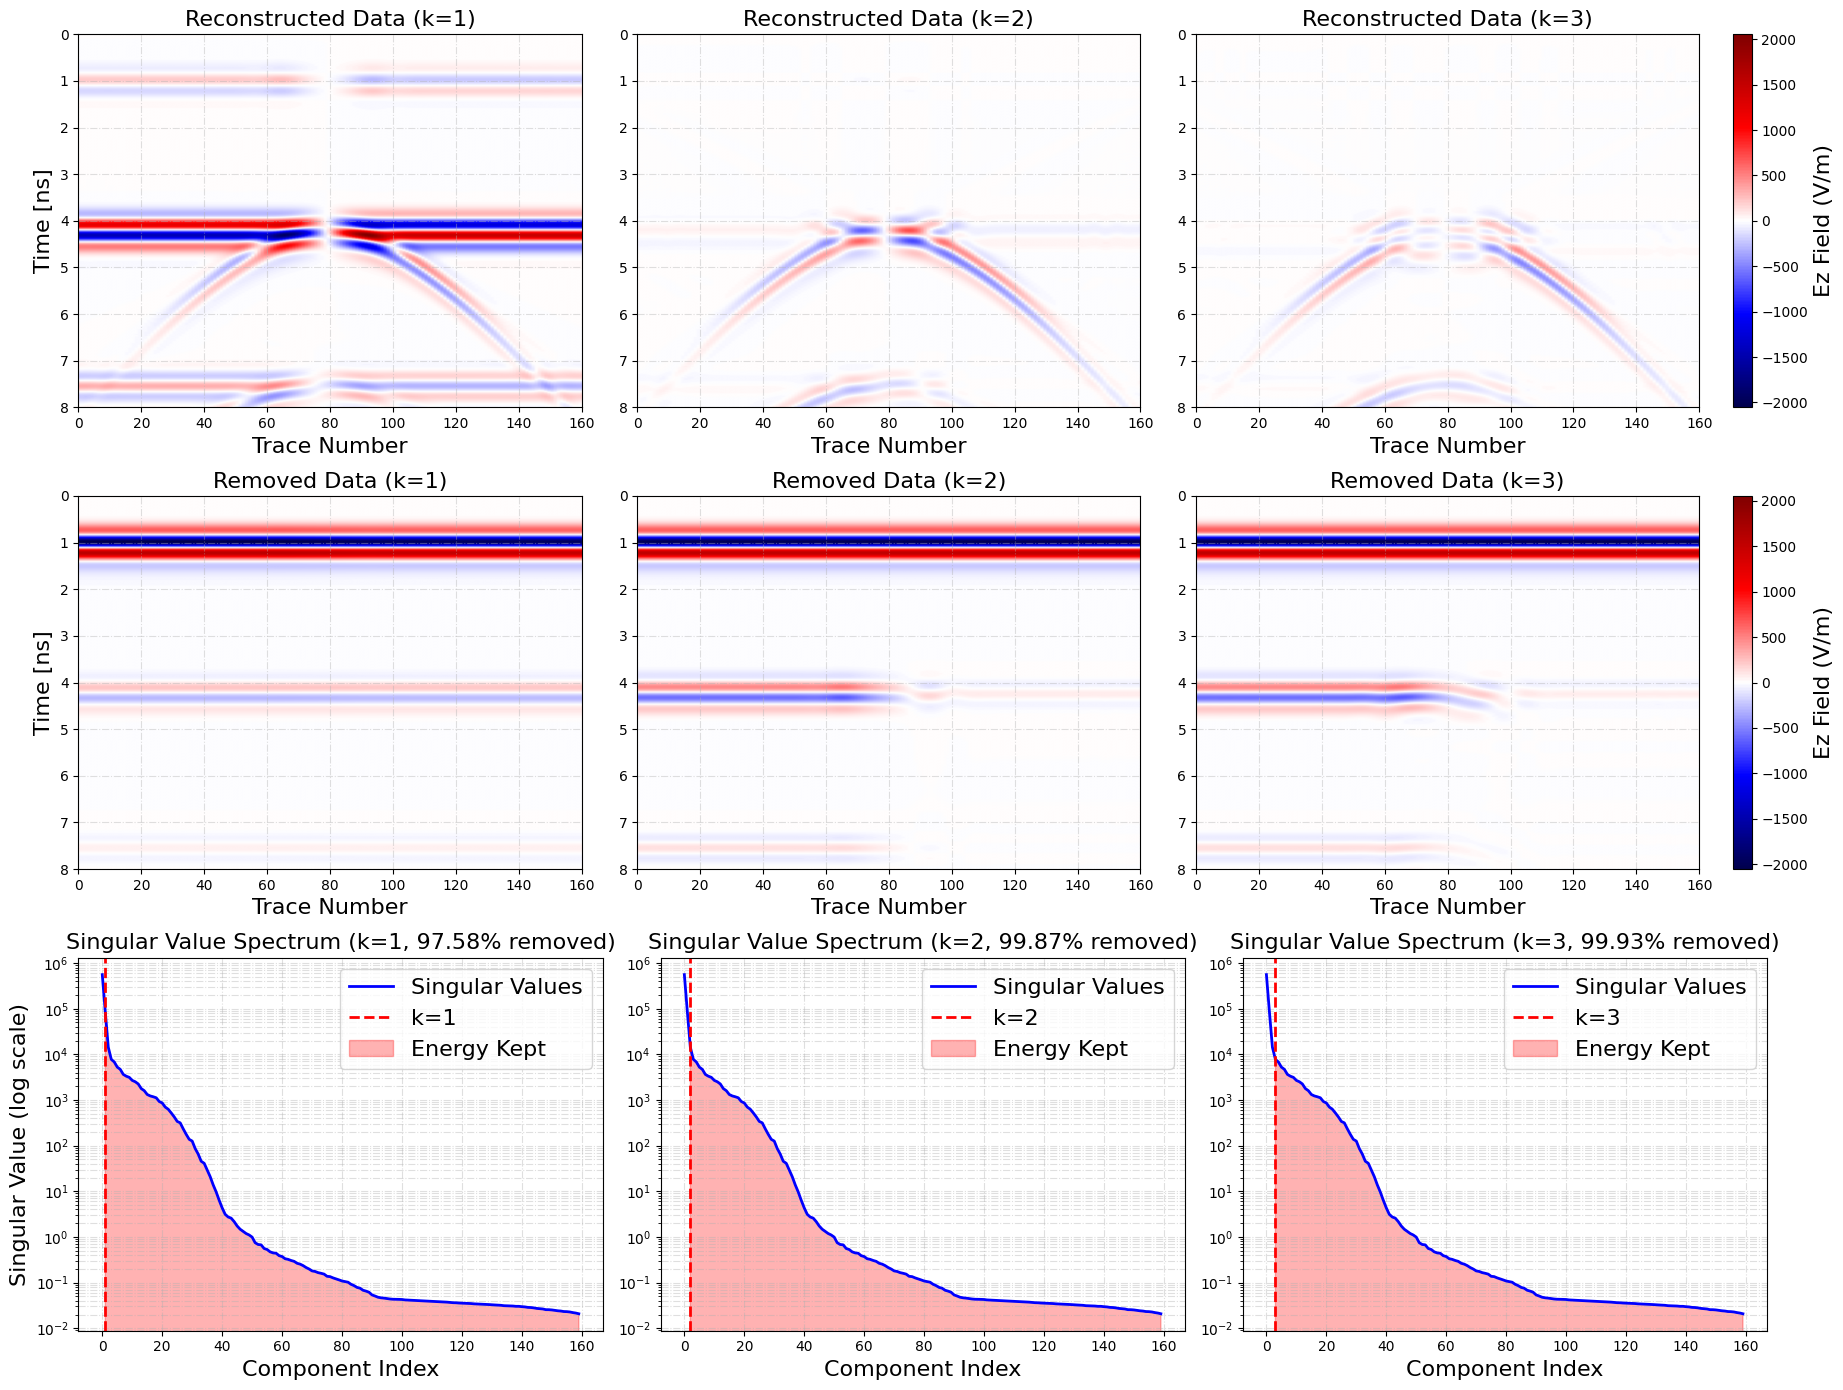

In [53]:
process_2_SVD = process_2_GPRData_object.data.copy()

# SVD analysis on raw data
U, S, Vt = np.linalg.svd(process_2_SVD, full_matrices=False)

# Reconstruct data using different k values
k_values = [1, 2, 3]
reconstructed_data = []
removed_data = []

for k in k_values:
    S_k = np.zeros_like(S)
    S_k[k:] = S[k:]  # Keep only components from k onwards
    process_2_reconstructed = U @ np.diag(S_k) @ Vt
    reconstructed_data.append(process_2_reconstructed)
    removed_data.append(process_2_SVD - process_2_reconstructed)

# Compute cumulative energy
total_energy = np.sum(S**2)
cumulative_energy = np.cumsum(S**2) / total_energy * 100

# Comon colour scale per row
vmin_top = -np.amax([np.abs(d).max() for d in reconstructed_data])
vmax_top =  np.amax([np.abs(d).max() for d in reconstructed_data])

vmin_middle = -np.amax([np.abs(d).max() for d in removed_data])
vmax_middle =  np.amax([np.abs(d).max() for d in removed_data])

# Create 3x3 subplot grid
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

# Row 1: Reconstructed data
for i, (k, data) in enumerate(zip(k_values, reconstructed_data)):
    im = axes[0, i].imshow(data[:,:], cmap='seismic', aspect='auto',
                       extent=extent, vmin=vmin_top, vmax=vmax_top)
    axes[0, i].set_title(f'Reconstructed Data (k={k})', fontsize=16)
    axes[0, i].set_xlabel('Trace Number', fontsize=16)
    if i == 0:
        axes[0, i].set_ylabel('Time [ns]', fontsize=16)
    axes[0, i].grid(which='both', axis='both', linestyle='-.', alpha=0.4)
    # fig.colorbar(im, ax=axes[0, i], fraction=0.046, pad=0.04)

# Row 2: Removed data (difference)
for i, (k, data) in enumerate(zip(k_values, removed_data)):
    im = axes[1, i].imshow(data[:,:], cmap='seismic', aspect='auto',
                            extent=extent, vmin=vmin_middle, vmax=vmax_middle)
    axes[1, i].set_title(f'Removed Data (k={k})', fontsize=16)
    axes[1, i].set_xlabel('Trace Number', fontsize=16)
    if i == 0:
        axes[1, i].set_ylabel('Time [ns]', fontsize=16)
    axes[1, i].grid(which='both', axis='both', linestyle='-.', alpha=0.4)
    # fig.colorbar(im, ax=axes[1, i], fraction=0.046, pad=0.04)

# Row 3: Energy spectra
for i, k in enumerate(k_values):
    axes[2, i].semilogy(range(len(S)), S, 'b-', linewidth=2, label='Singular Values')
    axes[2, i].axvline(x=k, color='red', linestyle='--', linewidth=2, label=f'k={k}')
    axes[2, i].fill_between(range(k, len(S)), S[k:], alpha=0.3, color='red', label='Energy Kept')
    axes[2, i].set_title(f'Singular Value Spectrum (k={k}, {cumulative_energy[k-1]:.2f}% removed)', fontsize=16)
    axes[2, i].set_xlabel('Component Index', fontsize=16)
    if i == 0:
        axes[2, i].set_ylabel('Singular Value (log scale)', fontsize=16)
    axes[2, i].grid(which='both', axis='both', linestyle='-.', alpha=0.4)
    axes[2, i].legend(fontsize=16)

plt.tight_layout()

# Colorbars for each row
cbar1 = fig.colorbar(im, ax=axes[0, :], fraction=0.02, pad=0.02)
cbar1.set_label('Ez Field (V/m)', fontsize=16)
cbar2 = fig.colorbar(im, ax=axes[1, :], fraction=0.02, pad=0.02)
cbar2.set_label('Ez Field (V/m)', fontsize=16)

# save image
path = 'Images_Experiment_9\\Results\\Processing\\SVD_filtered.png'
plt.savefig(fname = path, bbox_inches='tight')

plt.show()


RPCA on raw data to remove the direct wave

In [54]:
process_2_RPCA = process_2_GPRData_object.data.copy()

nt = process_2_RPCA.shape[0]
nx = process_2_RPCA.shape[1]



k = [0.25, 0.40, 0.55]
lambda_values = [val / np.sqrt(max(nt, nx)) for val in k]


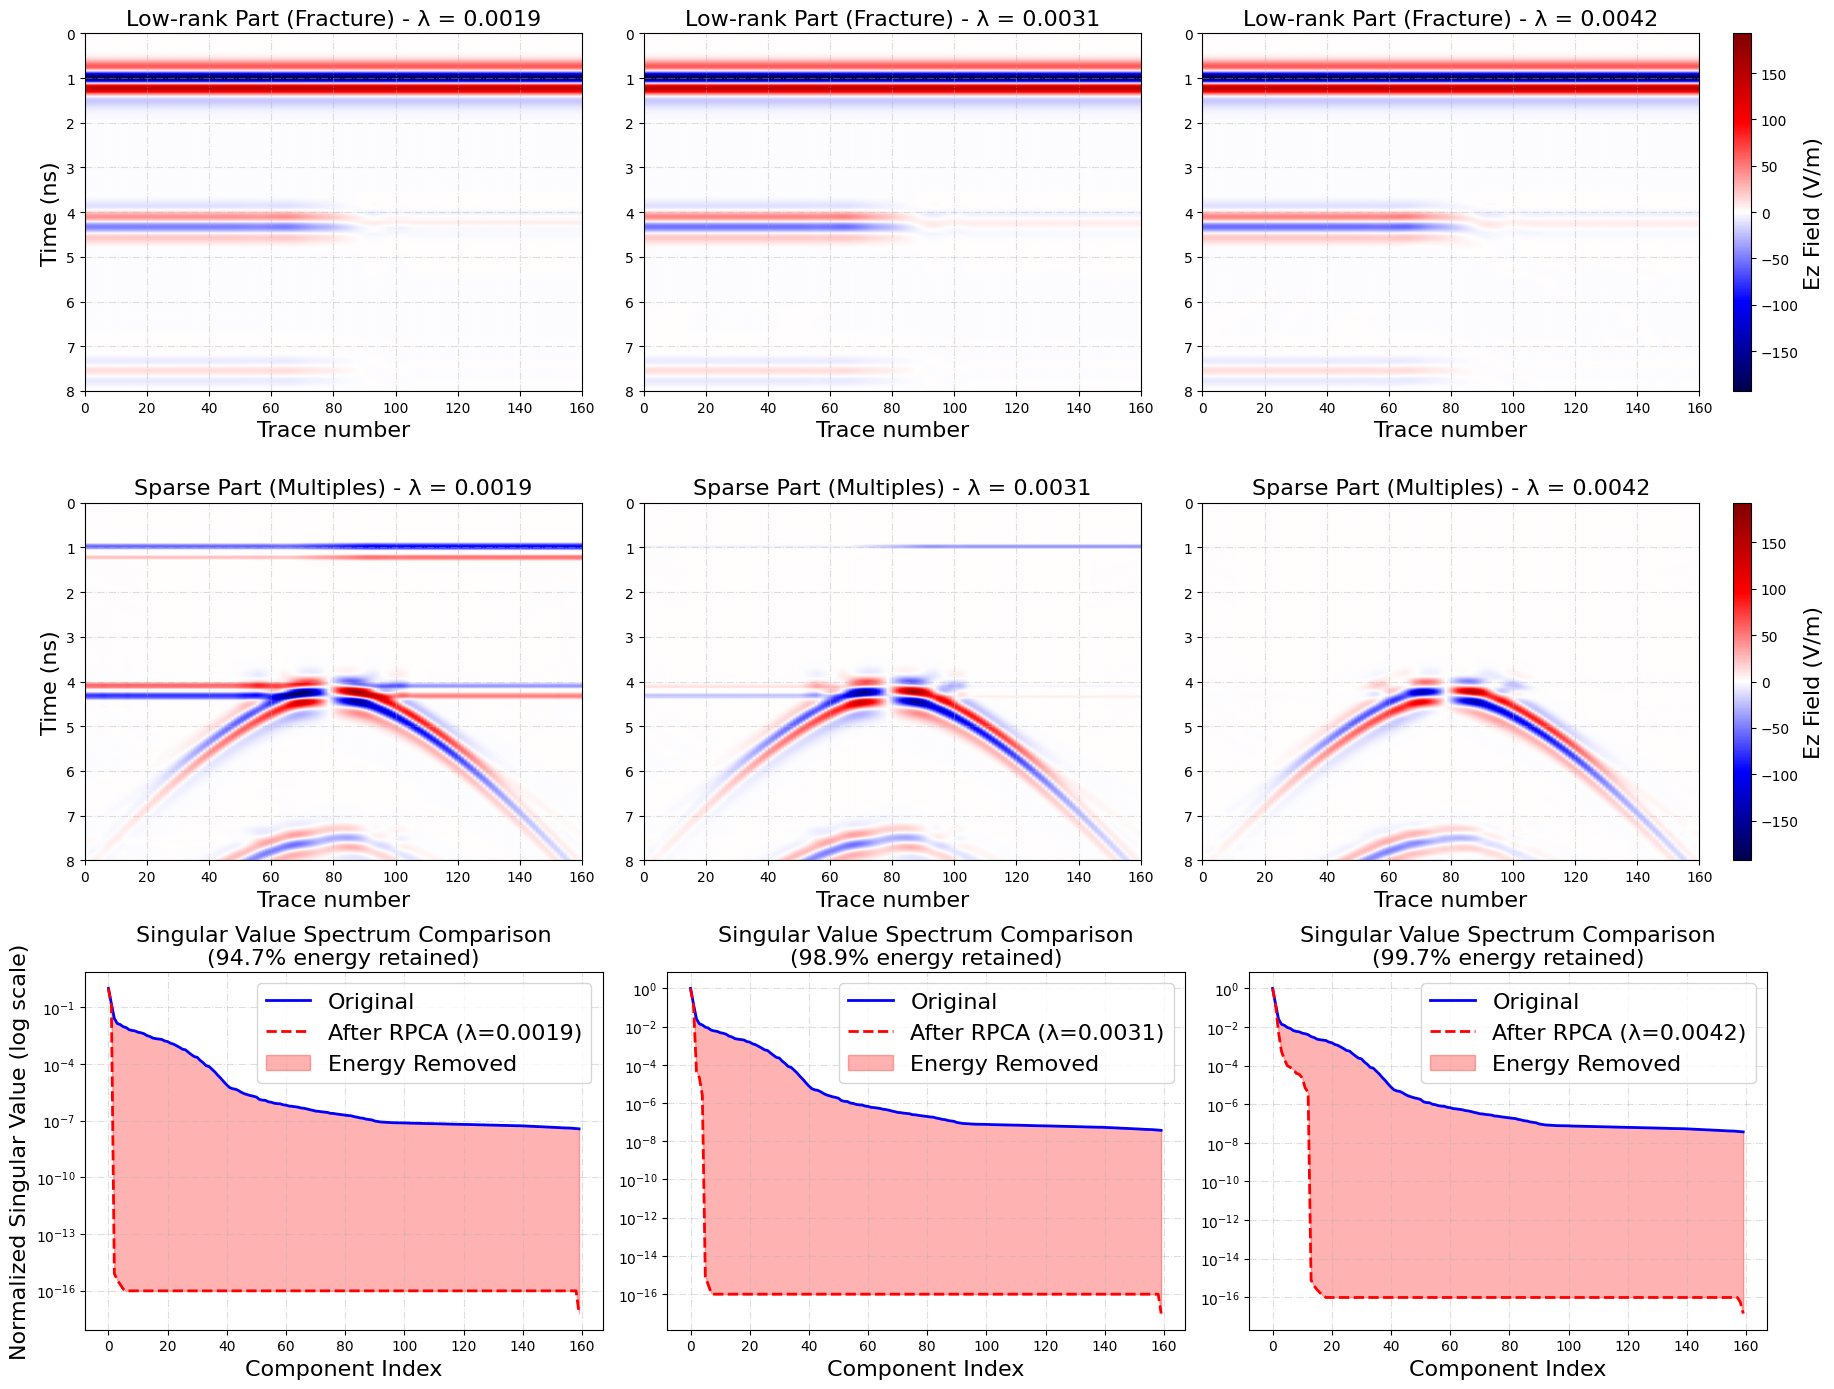

In [63]:
# Compute original SVD for energy spectrum
U_orig, S_orig, Vt_orig = np.linalg.svd(process_2_RPCA, full_matrices=False)
total_energy_orig = np.sum(S_orig**2)

# Lambda tuning
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

# Store results for color scale computation
L_results = []
S_results = []

for idx, Lambda in enumerate(lambda_values):
    L_temp, S_temp = rpca_ialm(process_2_RPCA.copy(), lam=Lambda)
    L_results.append(L_temp)
    S_results.append(S_temp)

# Compute common color scales per row
vmin_row1 = -np.amax([np.abs(L).max() for L in L_results])
vmax_row1 =  np.amax([np.abs(L).max() for L in L_results])

vmin_row2 = -np.amax([np.abs(S).max() for S in S_results])
vmax_row2 =  np.amax([np.abs(S).max() for S in S_results])

# Plot results
for idx, Lambda in enumerate(lambda_values):
    L_temp = L_results[idx]
    S_temp = S_results[idx]
    
    # Row 1: Low-rank components
    im = axes[0, idx].imshow(L_temp, aspect='auto', cmap='seismic', extent=extent,
                             vmin=vmin_row1, vmax=vmax_row1)
    axes[0, idx].set_title(f'Low-rank Part (Fracture) - λ = {Lambda:.4f}', fontsize=16)
    axes[0, idx].set_xlabel('Trace number', fontsize=16)
    if idx == 0:
        axes[0, idx].set_ylabel('Time (ns)', fontsize=16)
    axes[0, idx].grid(which='both', axis='both', linestyle='-.', alpha=0.4)
    
    # Row 2: Sparse components (multiples)
    im = axes[1, idx].imshow(S_temp, aspect='auto', cmap='seismic', extent=extent,
                             vmin=vmin_row2, vmax=vmax_row2)
    axes[1, idx].set_title(f'Sparse Part (Multiples) - λ = {Lambda:.4f}', fontsize=16)
    axes[1, idx].set_xlabel('Trace number', fontsize=16)
    if idx == 0:
        axes[1, idx].set_ylabel('Time (ns)', fontsize=16)
    axes[1, idx].grid(which='both', axis='both', linestyle='-.', alpha=0.4)
    
    # Row 3: Energy spectra comparison
    # Compute SVD of the low-rank component
    U_rpca, S_rpca, Vt_rpca = np.linalg.svd(L_temp, full_matrices=False)
    total_energy_rpca = np.sum(S_rpca**2)
    
    # Plot original and RPCA spectra
    axes[2, idx].semilogy(range(len(S_orig)), S_orig / np.linalg.norm(S_orig), 'b-', linewidth=2, label='Original')
    axes[2, idx].semilogy(range(len(S_rpca)), S_rpca / np.linalg.norm(S_rpca), 'r--', linewidth=2, label=f'After RPCA (λ={Lambda:.4f})')
    axes[2, idx].fill_between(range(len(S_rpca)), S_rpca / np.linalg.norm(S_rpca), 
                              S_orig[:len(S_rpca)] / np.linalg.norm(S_orig), 
                              alpha=0.3, color='red', label='Energy Removed')
    axes[2, idx].set_title(f'Singular Value Spectrum Comparison\n({100 * total_energy_rpca / total_energy_orig:.1f}% energy retained)', fontsize=16)
    axes[2, idx].set_xlabel('Component Index', fontsize=16)
    if idx == 0:
        axes[2, idx].set_ylabel('Normalized Singular Value (log scale)', fontsize=16)
    axes[2, idx].grid(which='both', axis='both', linestyle='-.', alpha=0.4)
    axes[2, idx].legend(fontsize=16)

plt.tight_layout()

# Colorbars for each row
cbar1 = fig.colorbar(im, ax=axes[0, :], fraction=0.02, pad=0.02)
cbar1.set_label('Ez Field (V/m)', fontsize=16)
cbar2 = fig.colorbar(im, ax=axes[1, :], fraction=0.02, pad=0.02)
cbar2.set_label('Ez Field (V/m)', fontsize=16)

# save image
path = 'Images_Experiment_9\\Results\\Processing\\RPCA_filtered.png'
plt.savefig(fname = path, bbox_inches='tight')

plt.show()


Horizontal Filter

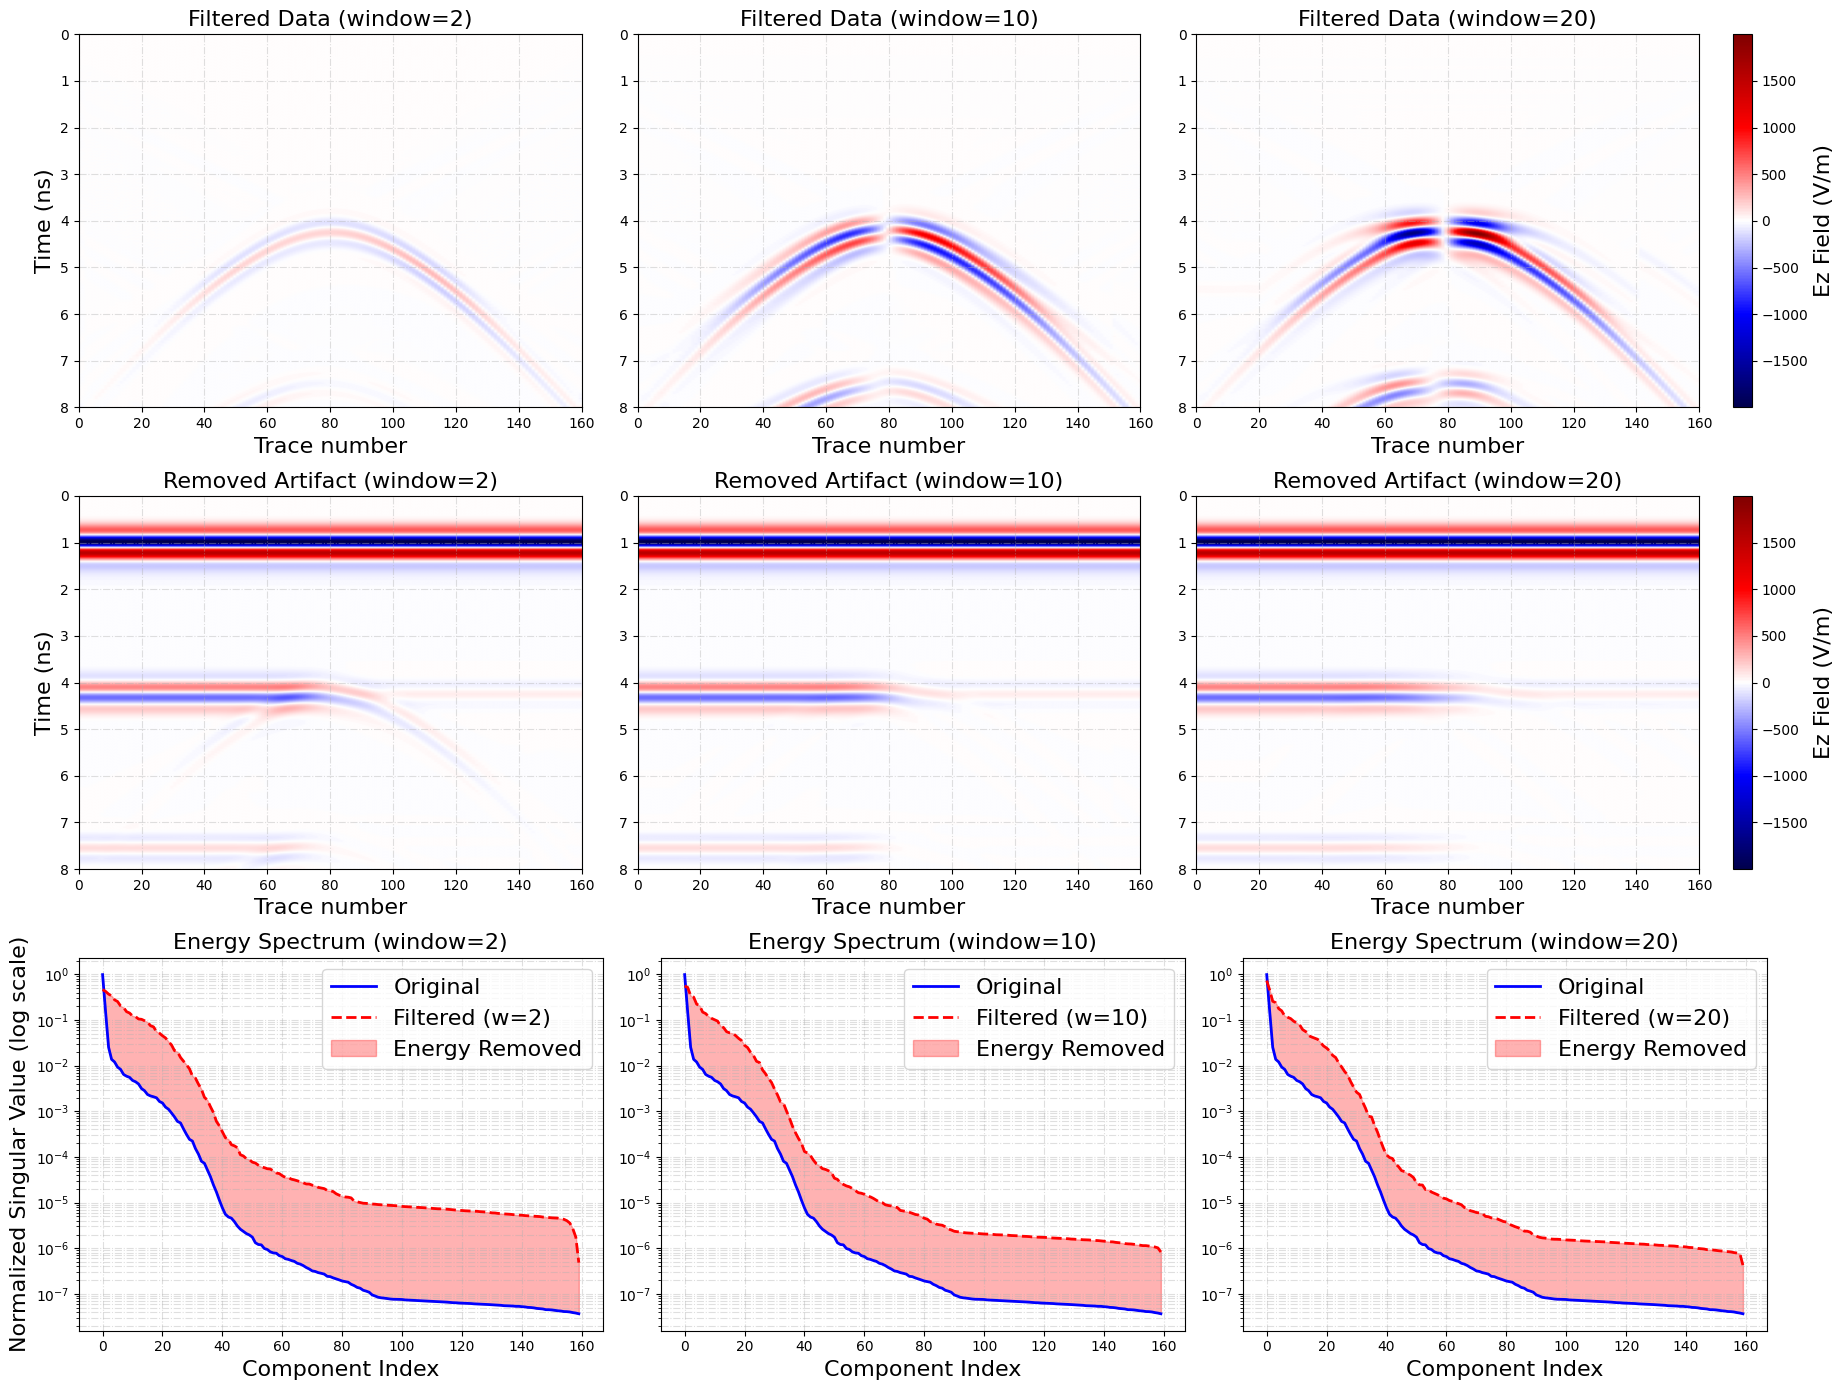

In [64]:
# Apply horizontal filter with different window sizes
window_sizes = [2, 10, 20]
filtered_results = []
removed_results = []

for ws in window_sizes:
    process_2_HF_temp = process_2_GPRData_object.copy()
    process_2_HF_temp = process_2_HF_temp.preprocessing.horizontal_filter(ws)
    filtered_results.append(process_2_HF_temp.data)
    removed_results.append(process_2_GPRData_object.data - process_2_HF_temp.data)

# Compute SVD for energy spectrum analysis
U_orig, S_orig, Vt_orig = np.linalg.svd(process_2_GPRData_object.data, full_matrices=False)

# Compute common color scales per row
vmin_row1 = -np.amax([np.abs(d).max() for d in filtered_results])
vmax_row1 =  np.amax([np.abs(d).max() for d in filtered_results])

vmin_row2 = -np.amax([np.abs(d).max() for d in removed_results])
vmax_row2 =  np.amax([np.abs(d).max() for d in removed_results])

# Create 3x3 subplot grid
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

# Row 1: Filtered data
for i, (ws, filtered) in enumerate(zip(window_sizes, filtered_results)):
    im = axes[0, i].imshow(filtered, aspect='auto', cmap='seismic', extent=extent,
                           vmin=vmin_row1, vmax=vmax_row1)
    axes[0, i].set_title(f'Filtered Data (window={ws})', fontsize=16)
    axes[0, i].set_xlabel('Trace number', fontsize=16)
    if i == 0:
        axes[0, i].set_ylabel('Time (ns)', fontsize=16)
    axes[0, i].grid(which='both', axis='both', linestyle='-.', alpha=0.4)

# Row 2: Removed artifact
for i, (ws, removed) in enumerate(zip(window_sizes, removed_results)):
    im = axes[1, i].imshow(removed, aspect='auto', cmap='seismic', extent=extent,
                           vmin=vmin_row2, vmax=vmax_row2)
    axes[1, i].set_title(f'Removed Artifact (window={ws})', fontsize=16)
    axes[1, i].set_xlabel('Trace number', fontsize=16)
    if i == 0:
        axes[1, i].set_ylabel('Time (ns)', fontsize=16)
    axes[1, i].grid(which='both', axis='both', linestyle='-.', alpha=0.4)

# Row 3: Energy spectra for each filtered result
for i, (ws, filtered) in enumerate(zip(window_sizes, filtered_results)):
    U_filt, S_filt, Vt_filt = np.linalg.svd(filtered, full_matrices=False)
    
    axes[2, i].semilogy(range(len(S_orig)), S_orig / np.linalg.norm(S_orig), 'b-', linewidth=2, label='Original')
    axes[2, i].semilogy(range(len(S_filt)), S_filt / np.linalg.norm(S_filt), 'r--', linewidth=2, label=f'Filtered (w={ws})')
    axes[2, i].fill_between(range(len(S_filt)), S_filt / np.linalg.norm(S_filt), 
                            S_orig[:len(S_filt)] / np.linalg.norm(S_orig), 
                            alpha=0.3, color='red', label='Energy Removed')
    axes[2, i].set_title(f'Energy Spectrum (window={ws})', fontsize=16)
    axes[2, i].set_xlabel('Component Index', fontsize=16)
    if i == 0:
        axes[2, i].set_ylabel('Normalized Singular Value (log scale)', fontsize=16)
    axes[2, i].grid(which='both', axis='both', linestyle='-.', alpha=0.4)
    axes[2, i].legend(fontsize=16)

plt.tight_layout()

# Colorbars for each row
cbar1 = fig.colorbar(im, ax=axes[0, :], fraction=0.02, pad=0.02)
cbar1.set_label('Ez Field (V/m)', fontsize=16)
cbar2 = fig.colorbar(im, ax=axes[1, :], fraction=0.02, pad=0.02)
cbar2.set_label('Ez Field (V/m)', fontsize=16)

# save image
path = 'Images_Experiment_9\\Results\\Processing\\Horizontal_filtered.png'
plt.savefig(fname = path, bbox_inches='tight')

plt.show()


All these methods not only removed the direct wave but also the horizontal fracture...

Direct wave subtraction

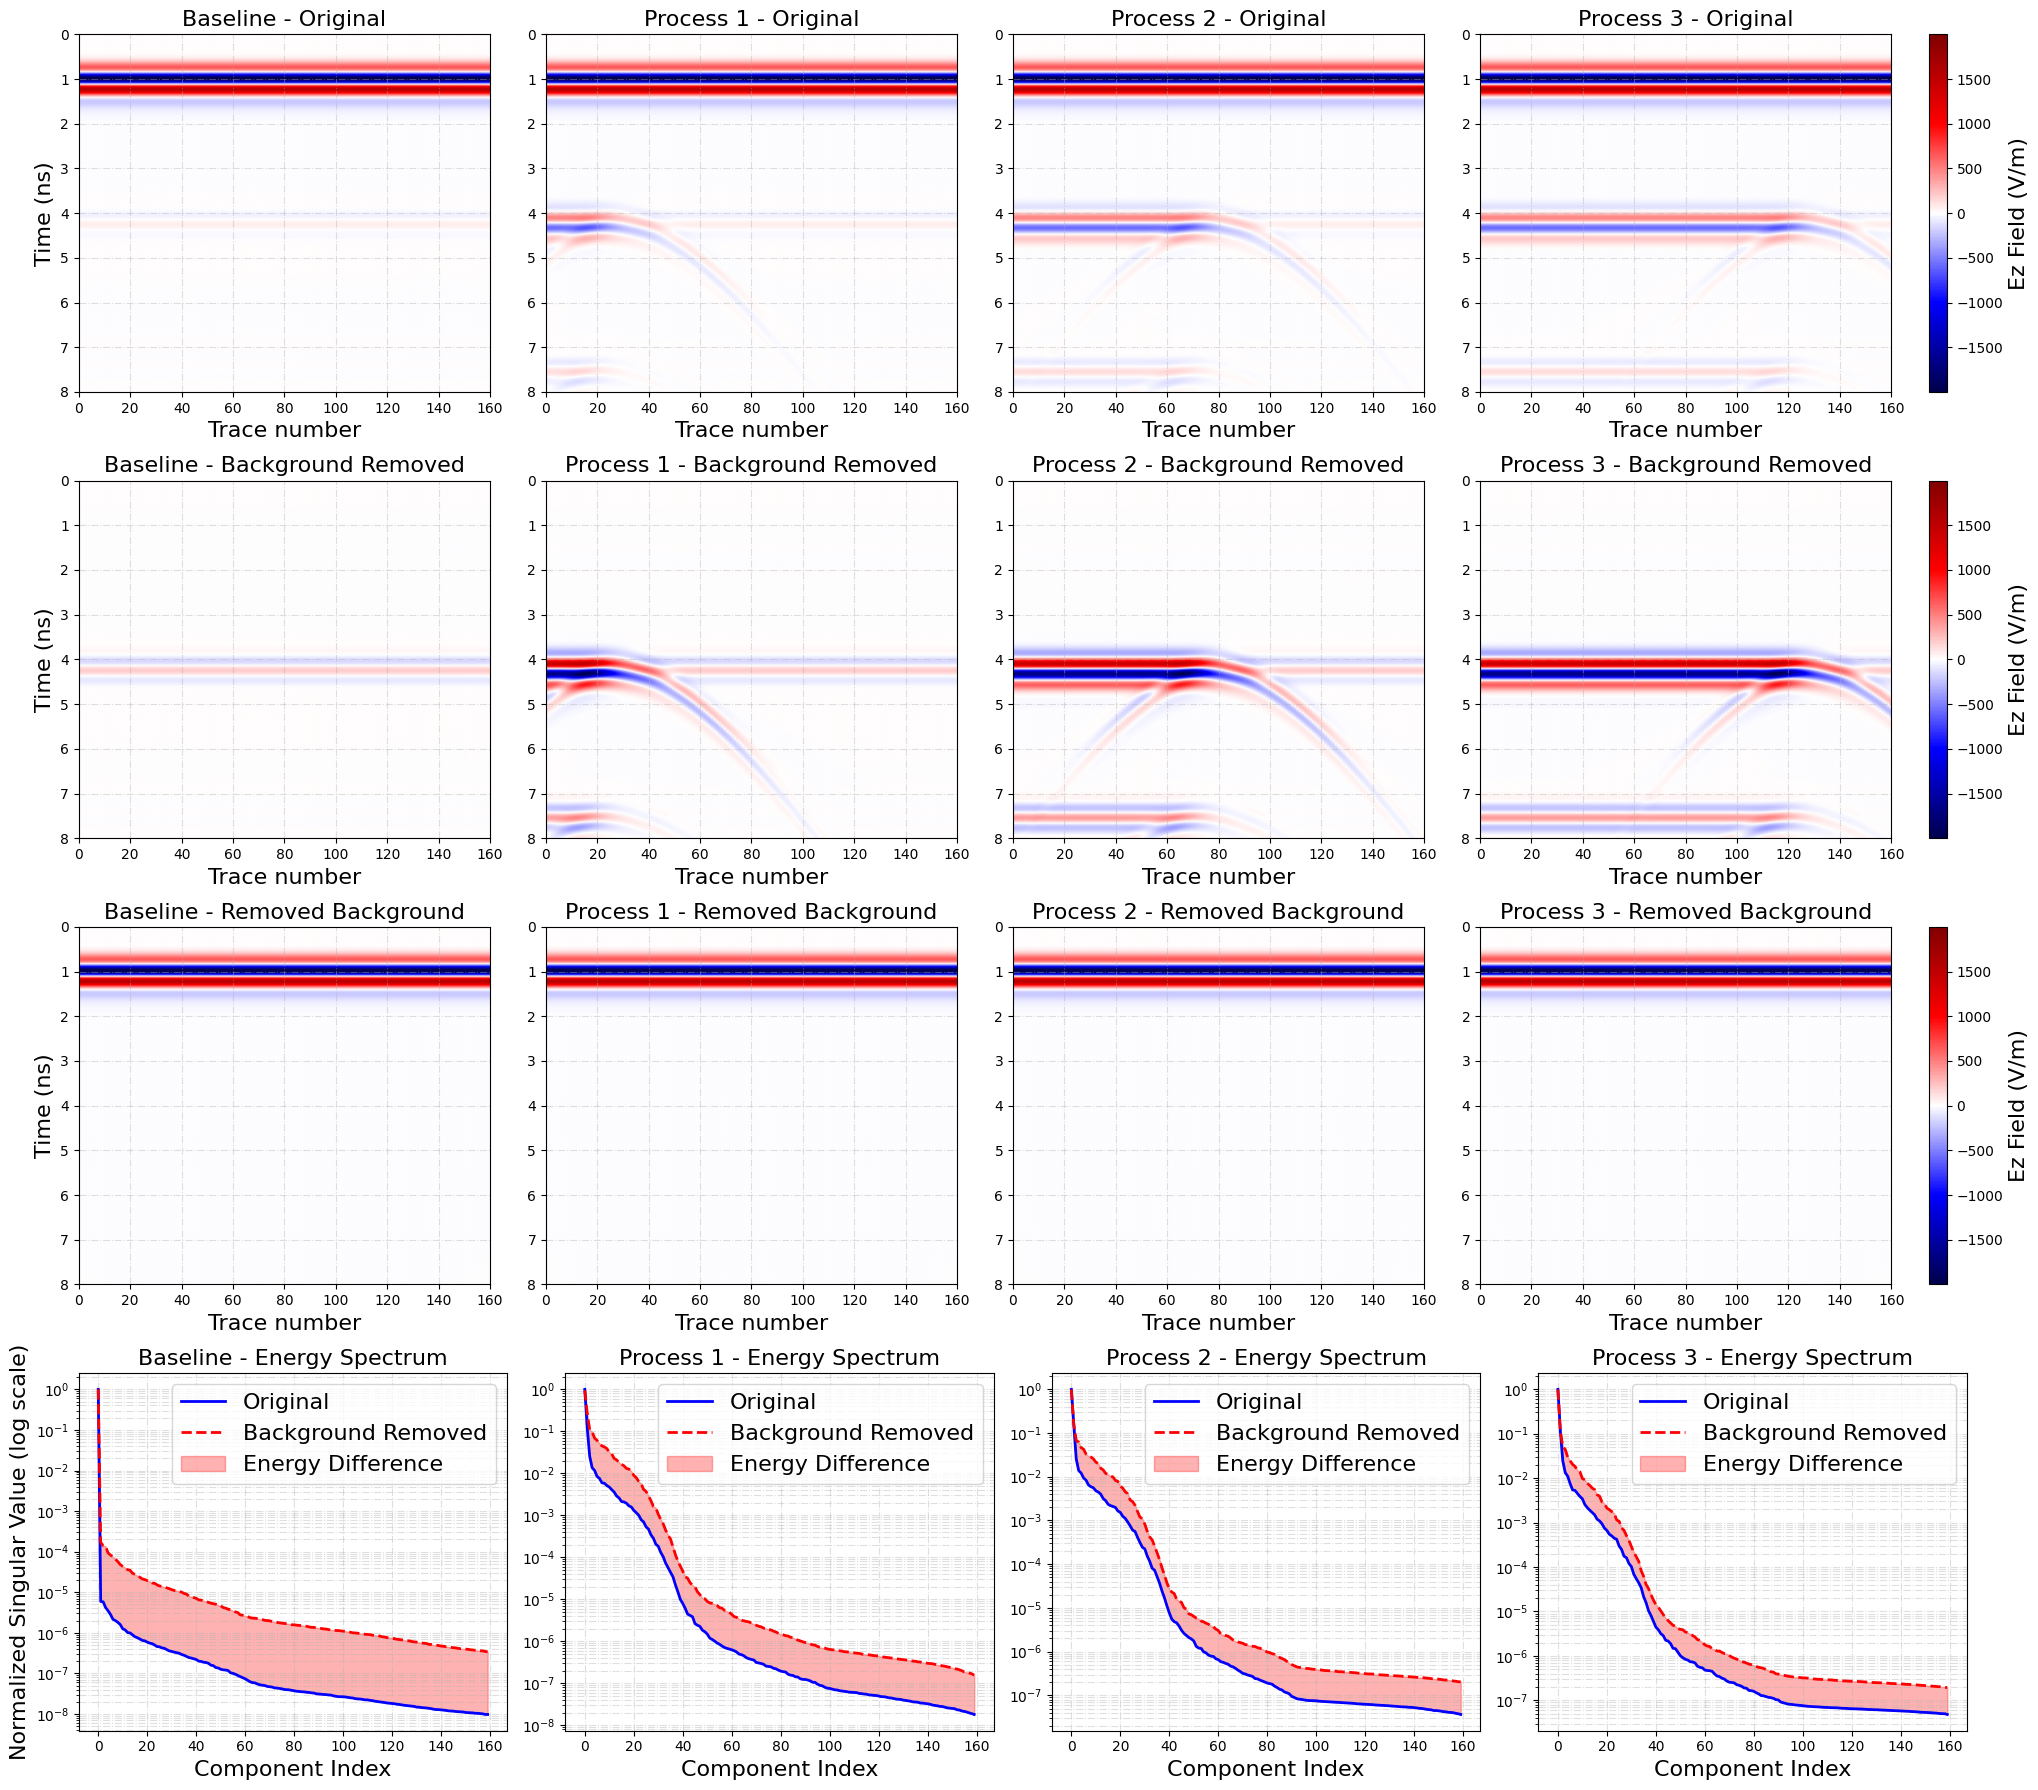

In [59]:
# Apply background subtraction to all datasets
baseline_minus_background  = baseline_GPRData_object.data - background_GPRData_object.data
process_1_minus_background = process_1_GPRData_object.data - background_GPRData_object.data
process_2_minus_background = process_2_GPRData_object.data - background_GPRData_object.data
process_3_minus_background = process_3_GPRData_object.data - background_GPRData_object.data

# Create list of datasets and titles
datasets = [baseline_minus_background, process_1_minus_background, 
            process_2_minus_background, process_3_minus_background]
original_datasets = [baseline_GPRData_object.data, process_1_GPRData_object.data,
                     process_2_GPRData_object.data, process_3_GPRData_object.data]
titles = ['Baseline', 'Process 1', 'Process 2', 'Process 3']

# Compute SVD for original background (for energy spectrum comparison)
U_bg, S_bg, Vt_bg = np.linalg.svd(background_GPRData_object.data, full_matrices=False)

# Compute common color scales per row
vmin_row0 = -np.amax([np.abs(d).max() for d in original_datasets])
vmax_row0 =  np.amax([np.abs(d).max() for d in original_datasets])

vmin_row1 = -np.amax([np.abs(d).max() for d in datasets])
vmax_row1 =  np.amax([np.abs(d).max() for d in datasets])

vmin_row2 = -np.abs(background_GPRData_object.data).max()
vmax_row2 =  np.abs(background_GPRData_object.data).max()

# Create 4x4 subplot grid (add a row for original data)
fig, axes = plt.subplots(4, 4, figsize=(20, 18))

# Row 1: Original data
for i, (orig_data, title) in enumerate(zip(original_datasets, titles)):
    im = axes[0, i].imshow(orig_data, aspect='auto', cmap='seismic', extent=extent,
                           vmin=vmin_row0, vmax=vmax_row0)
    axes[0, i].set_title(f'{title} - Original', fontsize=16)
    axes[0, i].set_xlabel('Trace number', fontsize=16)
    if i == 0:
        axes[0, i].set_ylabel('Time (ns)', fontsize=16)
    axes[0, i].grid(which='both', axis='both', linestyle='-.', alpha=0.4)

# Row 2: Background-subtracted data (reconstructed)
for i, (data, title) in enumerate(zip(datasets, titles)):
    im = axes[1, i].imshow(data, aspect='auto', cmap='seismic', extent=extent,
                           vmin=vmin_row1, vmax=vmax_row1)
    axes[1, i].set_title(f'{title} - Background Removed', fontsize=16)
    axes[1, i].set_xlabel('Trace number', fontsize=16)
    if i == 0:
        axes[1, i].set_ylabel('Time (ns)', fontsize=16)
    axes[1, i].grid(which='both', axis='both', linestyle='-.', alpha=0.4)

# Row 3: Removed background component
for i, title in enumerate(titles):
    im = axes[2, i].imshow(background_GPRData_object.data, aspect='auto', cmap='seismic', extent=extent,
                           vmin=vmin_row2, vmax=vmax_row2)
    axes[2, i].set_title(f'{title} - Removed Background', fontsize=16)
    axes[2, i].set_xlabel('Trace number', fontsize=16)
    if i == 0:
        axes[2, i].set_ylabel('Time (ns)', fontsize=16)
    axes[2, i].grid(which='both', axis='both', linestyle='-.', alpha=0.4)

# Row 4: Energy spectra comparison
for i, (orig_data, bg_removed_data, title) in enumerate(zip(original_datasets, datasets, titles)):
    # Compute SVD for original and background-removed data
    U_orig, S_orig, Vt_orig = np.linalg.svd(orig_data, full_matrices=False)
    U_bgr, S_bgr, Vt_bgr = np.linalg.svd(bg_removed_data, full_matrices=False)
    
    axes[3, i].semilogy(range(len(S_orig)), S_orig / np.linalg.norm(S_orig), 'b-', linewidth=2, label='Original')
    axes[3, i].semilogy(range(len(S_bgr)), S_bgr / np.linalg.norm(S_bgr), 'r--', linewidth=2, label='Background Removed')
    axes[3, i].fill_between(range(len(S_bgr)), S_bgr / np.linalg.norm(S_bgr), 
                            S_orig[:len(S_bgr)] / np.linalg.norm(S_orig), 
                            alpha=0.3, color='red', label='Energy Difference')
    axes[3, i].set_title(f'{title} - Energy Spectrum', fontsize=16)
    axes[3, i].set_xlabel('Component Index', fontsize=16)
    if i == 0:
        axes[3, i].set_ylabel('Normalized Singular Value (log scale)', fontsize=16)
    axes[3, i].grid(which='both', axis='both', linestyle='-.', alpha=0.4)
    axes[3, i].legend(fontsize=16)

plt.tight_layout()
# Colorbars for each image row
cbar1 = fig.colorbar(im, ax=axes[0, :], fraction=0.02, pad=0.02)
cbar1.set_label('Ez Field (V/m)', fontsize=16)
cbar2 = fig.colorbar(im, ax=axes[1, :], fraction=0.02, pad=0.02)
cbar2.set_label('Ez Field (V/m)', fontsize=16)
cbar2 = fig.colorbar(im, ax=axes[2, :], fraction=0.02, pad=0.02)
cbar2.set_label('Ez Field (V/m)', fontsize=16)

# save image
path = 'Images_Experiment_9\\Results\\Processing\\Difference_filtered.png'
plt.savefig(fname = path, bbox_inches='tight')

plt.show()


Trigger flags on non-changed objects

In [60]:
# Set flags
diff_1_GPRData_object.preprocessing.remove_svd()
diff_2_GPRData_object.preprocessing.remove_svd()
diff_3_GPRData_object.preprocessing.remove_svd()

GPRData(samples=16960, traces=160, frequency=None MHz, time_window=None ns)

# 4. Converting to ImpDar objects

In [61]:
diff_1_Impdar_object = gprdata_to_impdar(diff_1_GPRData_object) # temporarily turned off self.attrs_optional testing in Impdar RadarData class for this to work
diff_2_Impdar_object = gprdata_to_impdar(diff_2_GPRData_object)
diff_3_Impdar_object = gprdata_to_impdar(diff_3_GPRData_object)

diff_1_Impdar_object.dist = receiver_positions
diff_2_Impdar_object.dist = receiver_positions
diff_3_Impdar_object.dist = receiver_positions

# 5. Time-Lapse

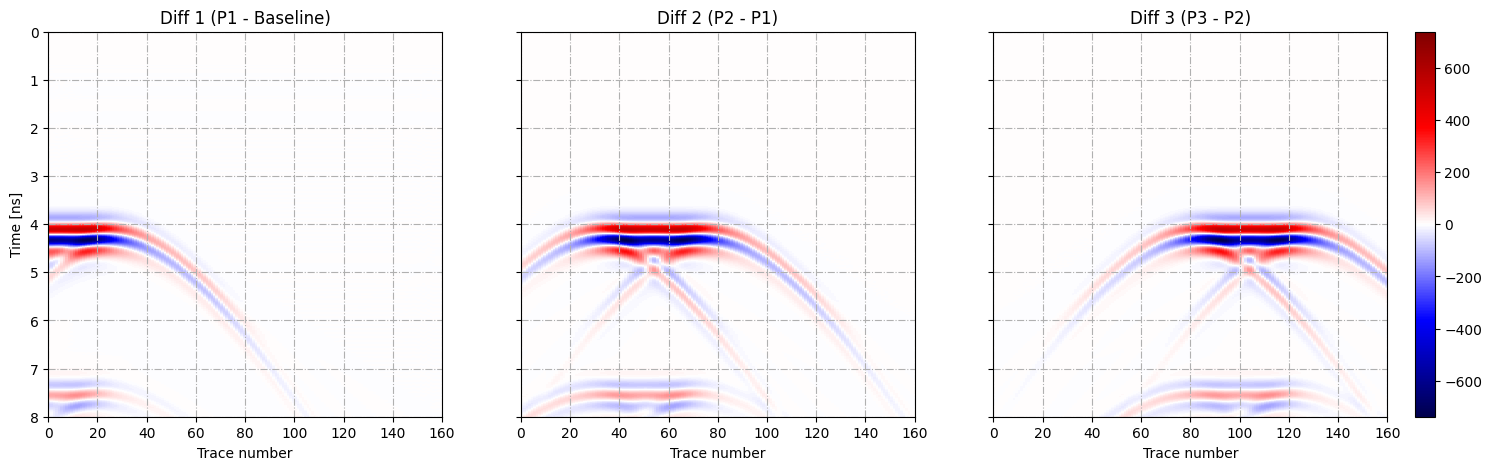

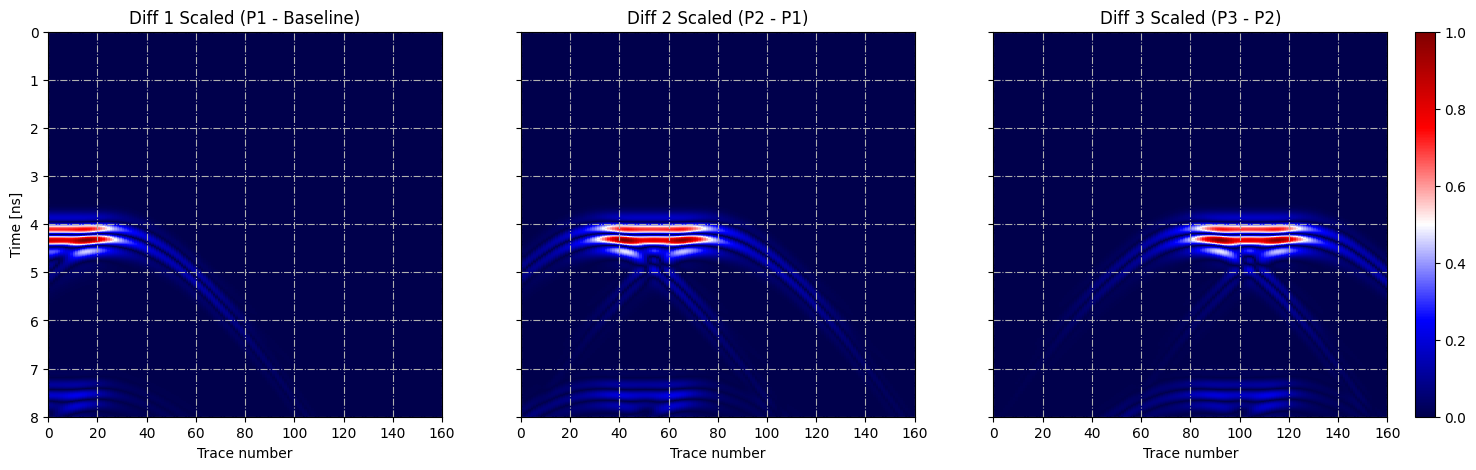

In [62]:

# Plotting: Scaled time-lapse differences (diff_1, diff_2, diff_3)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='w', edgecolor='w', sharex=True, sharey=True)

diff_data = [
    ("Diff 1 (P1 - Baseline)", diff_1),
    ("Diff 2 (P2 - P1)",       diff_2),
    ("Diff 3 (P3 - P2)",       diff_3),
]

diff_scaled_data = [
    ("Diff 1 Scaled (P1 - Baseline)", diff_1_scaled),
    ("Diff 2 Scaled (P2 - P1)",       diff_2_scaled),
    ("Diff 3 Scaled (P3 - P2)",       diff_3_scaled),
]

# compute common color scaling for unscaled differences
vmin_diff = -np.amax([np.abs(d).max() for _, d in diff_data])
vmax_diff =  np.amax([np.abs(d).max() for _, d in diff_data])

# Plot unscaled differences
for i, (title, data) in enumerate(diff_data):
    ax = axes[i]
    im = ax.imshow(data, aspect='auto', cmap='seismic', extent=extent, interpolation='nearest', vmin=vmin_diff, vmax=vmax_diff)
    ax.set_title(title)
    ax.set_xlabel('Trace number')
    if i == 0:
        ax.set_ylabel('Time [ns]')
    ax.grid(which='both', axis='both', linestyle='-.')

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)
# plt.tight_layout()

# save image
# path = 'Images_Experiment_9\\Results\\Processing\\Time_Lapse_Differences_Unscaled.png'
# plt.savefig(fname = path)

plt.show()

# Plot scaled differences in a separate figure
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5), facecolor='w', edgecolor='w', sharex=True, sharey=True)
for i, (title, data) in enumerate(diff_scaled_data):
    ax = axes2[i]
    im2 = ax.imshow(data, aspect='auto', cmap='seismic', extent=extent, interpolation='nearest')
    ax.set_title(title)
    ax.set_xlabel('Trace number')
    if i == 0:
        ax.set_ylabel('Time [ns]')
    ax.grid(which='both', axis='both', linestyle='-.')

fig2.colorbar(im2, ax=axes2, fraction=0.02, pad=0.02)
# plt.tight_layout()

# save image
# path2 = 'Images_Experiment_9\\Results\\Processing\\Time_Lapse_Differences_Scaled.png'
# plt.savefig(fname = path2)

plt.show()

# 7. Apply Degain

In [83]:
# # Apply de-gain to diff_1, diff_2, diff_3 and plot as 3 columns

# def apply_degain(data, row_cutoff, exp_power=-3):
#     data_degained = data.copy()
#     if row_cutoff < data_degained.shape[0]:
#         n_rows_below = data_degained.shape[0] - row_cutoff
#         degain_exp = np.exp(np.linspace(0, exp_power, n_rows_below))
#         data_degained[row_cutoff:, :] *= degain_exp[:, np.newaxis]
#     return data_degained

# # Inputs
# diff_data = [
#     ("Diff 1", diff_1_GPRData_object.data.copy()),
#     ("Diff 2", diff_2_GPRData_object.data.copy()),
#     ("Diff 3", diff_3_GPRData_object.data.copy()),
# ]

# row_cutoff = 1000

# # Apply de-gain
# processed = []
# for title, data in diff_data:
#     degained = apply_degain(data, row_cutoff=row_cutoff, exp_power=0)
#     processed.append((title, data, degained))


# # Compute common color scales per row
# originals = [p[1] for p in processed]
# degained_list = [p[2] for p in processed]
# differences = [degained - orig for _, orig, degained in processed]

# vmin_row0 = -np.amax([np.abs(d).max() for d in originals])
# vmax_row0 =  np.amax([np.abs(d).max() for d in originals])

# vmin_row1 = -np.amax([np.abs(d).max() for d in differences])
# vmax_row1 =  np.amax([np.abs(d).max() for d in differences])

# vmin_row2 = -np.amax([np.abs(d).max() for d in degained_list])
# vmax_row2 =  np.amax([np.abs(d).max() for d in degained_list])

# # Plot: 3 rows x 3 columns
# fig, axes = plt.subplots(3, 3, figsize=(20, 12), sharex=True, sharey=True)

# for col, (title, original, degained) in enumerate(processed):
#     # Row 1: Original with cutoff line
#     axes[0, col].imshow(original, aspect='auto', cmap='seismic', extent=extent,
#                         vmin=vmin_row0, vmax=vmax_row0)
#     axes[0, col].set_title(f'{title} - Original')
#     axes[0, col].axhline(y=extent[2] * (row_cutoff / original.shape[0]), color='red', linestyle='--', linewidth=2)
#     if col == 0:
#         axes[0, col].set_ylabel('Time (ns)')

#     # Row 2: Difference (degained - original)
#     axes[1, col].imshow(degained - original, aspect='auto', cmap='seismic', extent=extent,
#                         vmin=vmin_row1, vmax=vmax_row1)
#     axes[1, col].set_title(f'{title} - Difference')
#     if col == 0:
#         axes[1, col].set_ylabel('Time (ns)')

#     # Row 3: Degained
#     im = axes[2, col].imshow(degained, aspect='auto', cmap='seismic', extent=extent,
#                              vmin=vmin_row2, vmax=vmax_row2)
#     axes[2, col].set_title(f'{title} - De-gained')
#     axes[2, col].set_xlabel('Trace number')
#     if col == 0:
#         axes[2, col].set_ylabel('Time (ns)')

# for ax in axes.flat:
#     ax.grid(which='both', axis='both', linestyle='-.', alpha=0.4)

# plt.tight_layout()
# # Colorbars for each row
# fig.colorbar(im, ax=axes[0, :], fraction=0.02, pad=0.02)
# fig.colorbar(im, ax=axes[1, :], fraction=0.02, pad=0.02)
# fig.colorbar(im, ax=axes[2, :], fraction=0.02, pad=0.02)

# # save image
# path = 'Images_Experiment_9\\Results\\Processing\\Degain_filtered.png'
# plt.savefig(fname = path)

# plt.show()


# 7. Removing High Frequency Components

In [ ]:
# Function to apply hard cutoff filter with spectrum analysis
def apply_hard_cutoff(data, dt, cutoff_freq=20e9):
    # FFT
    fft_data = np.fft.rfft(data, axis=0)
    fft_freqs = np.fft.rfftfreq(data.shape[0], d=dt)

    # Store original spectrum magnitude
    orig_spectrum = np.abs(fft_data)

    # Apply Hard Cutoff (Zero out frequencies > cutoff_freq)
    mask = fft_freqs <= cutoff_freq
    fft_data_filtered = fft_data * mask[:, np.newaxis]

    # Store filtered spectrum magnitude
    filt_spectrum = np.abs(fft_data_filtered)

    # Inverse FFT
    data_filtered = np.fft.irfft(fft_data_filtered, n=data.shape[0], axis=0)
    return data_filtered, fft_freqs, orig_spectrum, filt_spectrum

# Inputs
diff_data = [
    ("Diff 1", diff_1_GPRData_object.data.copy()),
    ("Diff 2", diff_2_GPRData_object.data.copy()),
    ("Diff 3", diff_3_GPRData_object.data.copy()),
]

# Parameters
dt = time_axis[1] - time_axis[0]
cutoff_freq = 5e9

# Apply filter
processed = []
for title, data in diff_data:
    filtered, freqs, orig_spec, filt_spec = apply_hard_cutoff(data, dt, cutoff_freq)
    processed.append({
        'title': title,
        'original': data,
        'filtered': filtered,
        'freqs': freqs,
        'orig_spec': orig_spec,
        'filt_spec': filt_spec
    })

# Visualization
# Compute common color scales for spatial plots
originals = [p['original'] for p in processed]
filtered_list = [p['filtered'] for p in processed]

vmin_row0 = -np.amax([np.abs(d).max() for d in originals])
vmax_row0 =  np.amax([np.abs(d).max() for d in originals])

vmin_row2 = -np.amax([np.abs(d).max() for d in filtered_list])
vmax_row2 =  np.amax([np.abs(d).max() for d in filtered_list])

# Plot: 3 rows x 3 columns
fig, axes = plt.subplots(3, 3, figsize=(20, 15))

for col, p in enumerate(processed):
    title = p['title']
    
    # Row 1: Original Spatial
    im0 = axes[0, col].imshow(p['original'], aspect='auto', cmap='seismic', extent=extent,
                        vmin=vmin_row0, vmax=vmax_row0)
    axes[0, col].set_title(f'{title} - Original', fontsize=16)
    axes[0, col].set_xlabel('Trace number', fontsize=16)
    if col == 0:
        axes[0, col].set_ylabel('Time (ns)', fontsize=16)
    axes[0, col].grid(which='both', axis='both', linestyle='-.', alpha=0.4)

    # Row 2: Frequency Spectrum (Log-Log)
    # Average spectrum across all traces, ignoring DC component (index 0)
    avg_orig_spec = np.mean(p['orig_spec'], axis=1)
    avg_filt_spec = np.mean(p['filt_spec'], axis=1)
    
    # Slice to remove 0 Hz (DC) for log plot
    freqs_slice = p['freqs'][1:]
    orig_slice = avg_orig_spec[1:]
    filt_slice = avg_filt_spec[1:]
    
    axes[1, col].loglog(freqs_slice, orig_slice, label='Original', alpha=0.8)
    axes[1, col].loglog(freqs_slice, filt_slice, '--', label='Filtered', alpha=0.8)
    axes[1, col].axvline(x=cutoff_freq, color='r', linestyle=':', label=f'Cutoff {cutoff_freq/1e9} GHz')
    
    axes[1, col].set_title(f'{title} - Spectrum', fontsize=16)
    axes[1, col].set_xlabel('Frequency (Hz)', fontsize=16)
    if col == 0:
        axes[1, col].set_ylabel('Amplitude', fontsize=16)
    axes[1, col].legend(fontsize=16)
    axes[1, col].grid(True, which="both", ls="-", alpha=0.4)

    # Row 3: Filtered Spatial
    im2 = axes[2, col].imshow(p['filtered'], aspect='auto', cmap='seismic', extent=extent,
                             vmin=vmin_row2, vmax=vmax_row2)
    axes[2, col].set_title(f'{title} - Filtered (< {cutoff_freq/1e9} GHz)', fontsize=16)
    axes[2, col].set_xlabel('Trace number', fontsize=16)
    if col == 0:
        axes[2, col].set_ylabel('Time (ns)', fontsize=16)
    axes[2, col].grid(which='both', axis='both', linestyle='-.', alpha=0.4)

plt.tight_layout()

# Colorbars for spatial rows
cbar1 = fig.colorbar(im0, ax=axes[0, :], fraction=0.02, pad=0.02)
cbar1.set_label('Ez Field (V/m)', fontsize=16)
cbar2 = fig.colorbar(im2, ax=axes[2, :], fraction=0.02, pad=0.02)
cbar2.set_label('Ez Field (V/m)', fontsize=16)

# Save image
path = 'Images_Experiment_9\\Results\\Processing\\HighFreq_Removed_LogLog.png'
plt.savefig(fname = path, bbox_inches='tight')

plt.show()

# 8. Migration

Convert to Impdar Object

In [23]:
# Store degained data as GPRData objects
diff_1_degained_GPRData_object = GPRData(processed[0][2], background_gprMax_object.info)
diff_2_degained_GPRData_object = GPRData(processed[1][2], background_gprMax_object.info)
diff_3_degained_GPRData_object = GPRData(processed[2][2], background_gprMax_object.info)

In [24]:
# Convert degained GPRData objects to Impdar RadarData objects
diff_1_degained_Impdar_object  = gprdata_to_impdar(diff_1_degained_GPRData_object)
diff_2_degained_Impdar_object  = gprdata_to_impdar(diff_2_degained_GPRData_object)
diff_3_degained_Impdar_object  = gprdata_to_impdar(diff_3_degained_GPRData_object)

diff_1_degained_Impdar_object.dist = receiver_positions
diff_2_degained_Impdar_object.dist = receiver_positions
diff_3_degained_Impdar_object.dist = receiver_positions

Kirchhoff Migration

In [25]:
# import numPy files
receiver_positions = np.load('Experiment_9/infinite_fracture_receiver_positions.npy')
time_axis          = np.load('Experiment_9/infinite_fracture_time_axis.npy')
extent             = np.load('Experiment_9/infinite_fracture_extent.npy')

# Define depth samples and mean velocity for migration
depth_samples = np.linspace(0.0, 0.5, 1697)  # Depth samples from 0 to 0.5 m with 2 mm interval
mean_velocity = (3e8 / np.sqrt(6))  # Mean velocity in m/s
dt = time_axis[1] - time_axis[0] # s

background_gprMax_object.info

{'filepath': 'Experiment_9\\infinite_fracture_background_merged.out',
 'rx': 'rx1',
 'component': 'Ez',
 'samples': 16960,
 'traces': 160,
 'dt (ns)': 0.00047173086734993597,
 'frequency (GHz)': 2119.8528000038364,
 'iterations': 16960,
 'title': 'GPR Time-Lapse Subwavelength Resolution - Baseline',
 'gprmax_version': '3.1.7',
 'nrx': 1,
 'available_components': ['Ex', 'Ey', 'Ez', 'Hx', 'Hy', 'Hz'],
 'travel time (ns)': array([0.00000000e+00, 4.71730867e-04, 9.43461735e-04, ...,
        7.99914032e+00, 7.99961205e+00, 8.00008378e+00], shape=(16960,)),
 'time step (ns)': 0.00047173086734993597}

In [38]:
diff_1_Kirchhoff_Impdar_object = copy.deepcopy(diff_1_degained_Impdar_object)
diff_1_Kirchhoff_Impdar_object.dt = dt # s
diff_1_Kirchhoff_Impdar_object.snum = diff_1_degained_GPRData_object.data.shape[0]  # time steps
diff_1_Kirchhoff_Impdar_object.tnum = diff_1_degained_GPRData_object.data.shape[1]  # traces
diff_1_Kirchhoff_Impdar_object.travel_time = time_axis * 1e6  # s to microseconds
diff_1_Kirchhoff_Impdar_object.dist = receiver_positions / 1000 # m to km
diff_1_Kirchhoff_Impdar_object.trace_int = (receiver_positions[-1] - receiver_positions[0]) / (diff_1_Kirchhoff_Impdar_object.tnum - 1) / 1000 # m to km

diff_2_Kirchhoff_Impdar_object = copy.deepcopy(diff_2_degained_Impdar_object)
diff_2_Kirchhoff_Impdar_object.dt = dt # s
diff_2_Kirchhoff_Impdar_object.snum = diff_2_degained_GPRData_object.data.shape[0]  # time steps
diff_2_Kirchhoff_Impdar_object.tnum = diff_2_degained_GPRData_object.data.shape[1]  # traces
diff_2_Kirchhoff_Impdar_object.travel_time = time_axis * 1e6  # s to microseconds
diff_2_Kirchhoff_Impdar_object.dist = receiver_positions / 1000 # m to km
diff_2_Kirchhoff_Impdar_object.trace_int = (receiver_positions[-1] - receiver_positions[0]) / (diff_2_Kirchhoff_Impdar_object.tnum - 1) / 1000 # m to km

diff_3_Kirchhoff_Impdar_object = copy.deepcopy(diff_3_degained_Impdar_object)
diff_3_Kirchhoff_Impdar_object.dt = dt # s
diff_3_Kirchhoff_Impdar_object.snum = diff_3_degained_GPRData_object.data.shape[0]  # time steps
diff_3_Kirchhoff_Impdar_object.tnum = diff_3_degained_GPRData_object.data.shape[1]  # traces
diff_3_Kirchhoff_Impdar_object.travel_time = time_axis * 1e6  # s to microseconds
diff_3_Kirchhoff_Impdar_object.dist = receiver_positions / 1000 # m to km
diff_3_Kirchhoff_Impdar_object.trace_int = (receiver_positions[-1] - receiver_positions[0]) / (diff_3_Kirchhoff_Impdar_object.tnum - 1) / 1000 # m to km

In [22]:
diff_1_Kirchhoff_migrated = mig_python.migrationKirchhoff(diff_1_Kirchhoff_Impdar_object, mean_velocity, nearfield=True)
diff_2_Kirchhoff_migrated = mig_python.migrationKirchhoff(diff_2_Kirchhoff_Impdar_object, mean_velocity, nearfield=True)
diff_3_Kirchhoff_migrated = mig_python.migrationKirchhoff(diff_3_Kirchhoff_Impdar_object, mean_velocity, nearfield=True)

Kirchhoff Migration (diffraction summation) of 16960x160 matrix
Migrating trace number:
0, 

KeyboardInterrupt: 

In [34]:
from helper_functions import kirchhoff_migration


diff_1_Kirchhoff_migrated = kirchhoff_migration(diff_1_degained_GPRData_object.data, x=receiver_positions, t= time_axis, z=depth_samples, v=mean_velocity)
diff_2_Kirchhoff_migrated = kirchhoff_migration(diff_2_degained_GPRData_object.data, x=receiver_positions, t= time_axis, z=depth_samples, v=mean_velocity)
diff_3_Kirchhoff_migrated = kirchhoff_migration(diff_3_degained_GPRData_object.data, x=receiver_positions, t= time_axis, z=depth_samples, v=mean_velocity)

In [35]:
# Save the migrated data
np.save('Experiment_9/diff_1_Kirchhoff_migrated.npy', diff_1_Kirchhoff_migrated) 
np.save('Experiment_9/diff_2_Kirchhoff_migrated.npy', diff_2_Kirchhoff_migrated) 
np.save('Experiment_9/diff_3_Kirchhoff_migrated.npy', diff_3_Kirchhoff_migrated)

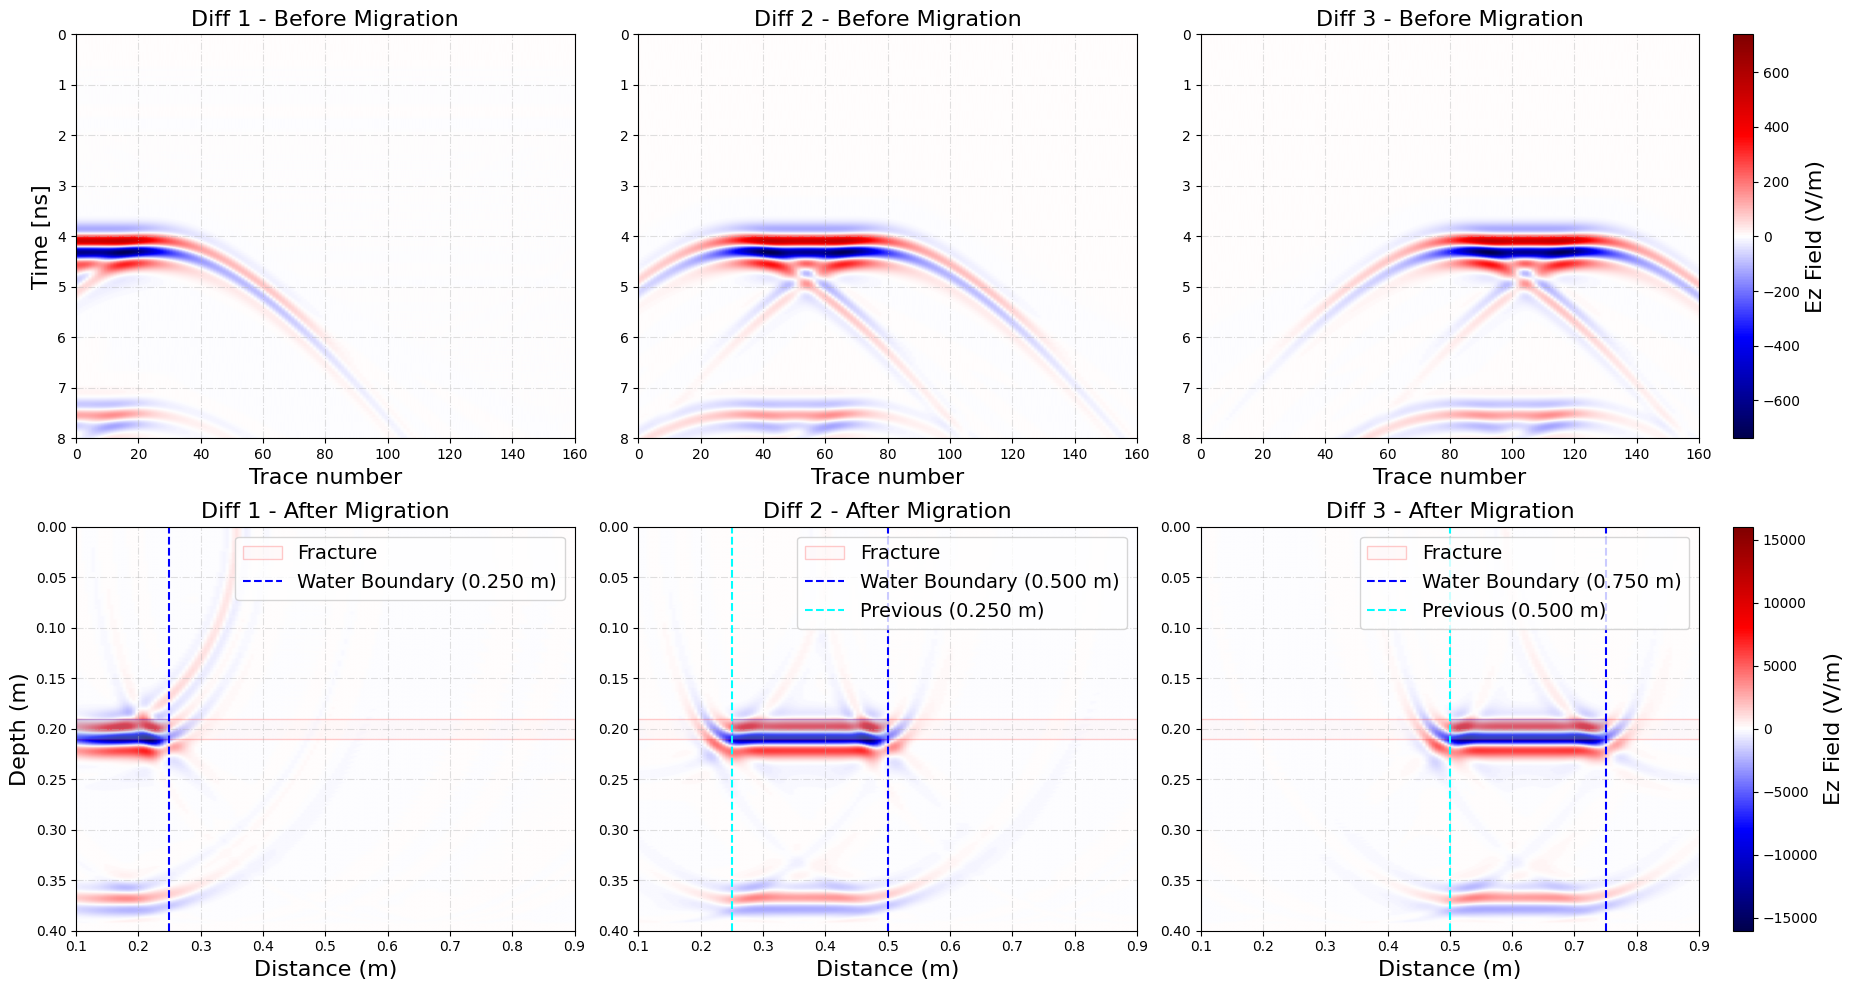

In [82]:
# Plot 2 rows x 3 columns: before and after migration for diff_1, diff_2, diff_3
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Data and water boundaries for each column
data_sets = [
    ('Diff 1', diff_1_degained_Impdar_object, diff_1_Kirchhoff_migrated, 0.0, 0.250),
    ('Diff 2', diff_2_degained_Impdar_object, diff_2_Kirchhoff_migrated, 0.250, 0.500),
    ('Diff 3', diff_3_degained_Impdar_object, diff_3_Kirchhoff_migrated, 0.500, 0.750),
]

x0 = 0.100
x1 = 0.900
depth = 0.4
fracture_y0 = depth - 0.190
fracture_y1 = depth - 0.210

# Compute common color scales per row
before_data_list = [ds[1].data for ds in data_sets]
after_data_list = [ds[2].data for ds in data_sets]

vmin_row0 = -np.amax([np.abs(d).max() for d in before_data_list])
vmax_row0 =  np.amax([np.abs(d).max() for d in before_data_list])

vmin_row1 = -np.amax([np.abs(d).max() for d in after_data_list])
vmax_row1 =  np.amax([np.abs(d).max() for d in after_data_list])

for col, (title, before_data, after_data, water_old, water_new) in enumerate(data_sets):
    # Row 1: Before migration
    im0 = axes[0, col].imshow(before_data.data, cmap='seismic', aspect='auto', extent=extent,
                        vmin=vmin_row0, vmax=vmax_row0)
    axes[0, col].set_title(f'{title} - Before Migration', fontsize=16)
    axes[0, col].set_xlabel('Trace number', fontsize=16)
    if col == 0:
        axes[0, col].set_ylabel('Time [ns]', fontsize=16)
    axes[0, col].grid(which='both', axis='both', linestyle='-.', alpha=0.4)
    
    # Row 2: After migration with overlays
    im1 = axes[1, col].imshow(after_data.data, cmap='seismic', aspect='auto', extent=[x0, x1, depth, 0],
                             vmin=vmin_row1, vmax=vmax_row1)
    axes[1, col].set_title(f'{title} - After Migration', fontsize=16)
    axes[1, col].set_xlabel('Distance (m)', fontsize=16)
    if col == 0:
        axes[1, col].set_ylabel('Depth (m)', fontsize=16)
    
    # Fracture zone
    axes[1, col].add_patch(Rectangle((x0, fracture_y0), x1 - x0, fracture_y1 - fracture_y0,
                                     facecolor='#ffe6e6', edgecolor='red', linewidth=1.0, alpha=0.2,
                                     label='Fracture'))
    
    # Water boundaries (only if they're within the plot range)
    if water_new > x0 and water_new < x1:
        axes[1, col].axvline(x=water_new, color='blue', linestyle='--', linewidth=1.5,
                            label=f'Water Boundary ({water_new:.3f} m)')
    
    if water_old > x0 and water_old < x1 and water_old != 0:
        axes[1, col].axvline(x=water_old, color='cyan', linestyle='--', linewidth=1.5,
                            label=f'Previous ({water_old:.3f} m)')
    
    # Water front (filled portion)
    if water_new > x0:
        fill_start = max(x0, water_old)
        fill_end = min(x1, water_new)
        if fill_start < fill_end:
            axes[1, col].add_patch(Rectangle((fill_start, fracture_y0), fill_end - fill_start, 
                                            fracture_y1 - fracture_y0,
                                            facecolor='#4da3ff', edgecolor='blue', alpha=0.2))
    
    axes[1, col].grid(which='both', axis='both', linestyle='-.', alpha=0.4)
    axes[1, col].legend(loc='upper right', fontsize=14)

# Set consistent y limits
# for ax in axes[0, :]:
#     ax.set_ylim(0, 8)

for ax in axes[1, :]:
    ax.set_ylim(depth, 0)

plt.tight_layout()
# Colorbars for each row
cbar1 = fig.colorbar(im0, ax=axes[0, :], fraction=0.02, pad=0.02)
cbar1.set_label('Ez Field (V/m)', fontsize=16)
cbar2 = fig.colorbar(im1, ax=axes[1, :], fraction=0.02, pad=0.02)
cbar2.set_label('Ez Field (V/m)', fontsize=16)


# save image
path = 'Images_Experiment_9\\Results\\Migrating\\Kirchhoff_migrated.png'
plt.savefig(fname = path, bbox_inches='tight')

plt.show()


In [ ]:
# # Perform Kirchhoff migration using the custom function (which has correct units)
# print("\nApplying Kirchhoff migration using custom kirchhoff_migration function...")
# print("=" * 70)

# depth_samples = np.linspace(0.0, 0.5, 1697)  # Depth samples from 0 to 0.5 m with 2 mm interval

# # The custom function expects data as (nt, nx) = (time_samples, traces)
# # Our GPRData has shape (time_samples, traces) already, so no transpose needed

# # Migrate each difference dataset
# diff_1_Kirchhoff_custom = kirchhoff_migration(
#     diff_1_degained_GPRData_object.data,  # Already (time, traces)
#     receiver_positions,
#     time_axis,
#     depth_samples,
#     mean_velocity
# )
# print("✓ diff_1 Kirchhoff migration complete")

# diff_2_Kirchhoff_custom = kirchhoff_migration(
#     diff_2_degained_GPRData_object.data,
#     receiver_positions,
#     time_axis,
#     depth_samples,
#     mean_velocity
# )
# print("✓ diff_2 Kirchhoff migration complete")

# diff_3_Kirchhoff_custom = kirchhoff_migration(
#     diff_3_degained_GPRData_object.data,
#     receiver_positions,
#     time_axis,
#     depth_samples,
#     mean_velocity
# )
# print("✓ diff_3 Kirchhoff migration complete")

# print("\nKirchhoff migration shapes:")
# print(f"  diff_1: {diff_1_Kirchhoff_custom.shape} (depth, traces)")
# print(f"  diff_2: {diff_2_Kirchhoff_custom.shape} (depth, traces)")
# print(f"  diff_3: {diff_3_Kirchhoff_custom.shape} (depth, traces)")

Phase-Shift Migration

In [39]:
diff_1_phaseshift_Impdar_object = copy.deepcopy(diff_1_degained_Impdar_object)
diff_2_phaseshift_Impdar_object = copy.deepcopy(diff_2_degained_Impdar_object)
diff_3_phaseshift_Impdar_object = copy.deepcopy(diff_3_degained_Impdar_object)

htaper = 75
vtaper = 75

diff_1_phaseshift_migrated = mig_python.migrationPhaseShift(diff_1_phaseshift_Impdar_object, htaper=htaper,vtaper=vtaper,vel=mean_velocity)
diff_2_phaseshift_migrated = mig_python.migrationPhaseShift(diff_2_phaseshift_Impdar_object, htaper=htaper,vtaper=vtaper,vel=mean_velocity)
diff_3_phaseshift_migrated = mig_python.migrationPhaseShift(diff_3_phaseshift_Impdar_object, htaper=htaper,vtaper=vtaper,vel=mean_velocity)



Phase-Shift Migration of 16960x160 matrix
Constant velocity 122.47448713915892 m/usec
Frequency: Frequency: 
0 MHz , 6469 MHz , 12938 MHz , 19407 MHz , 25877 MHz , 32346 MHz , 38815 MHz , 45284 MHz , 51754 MHz , 58223 MHz , 64692 MHz , 71162 MHz , 77631 MHz , 84100 MHz , 90569 MHz , 97039 MHz , 103508 MHz , 109977 MHz , 116446 MHz , 122916 MHz , 129385 MHz , 135854 MHz , 142324 MHz , 148793 MHz , 155262 MHz , 161731 MHz , 168201 MHz , 174670 MHz , 181139 MHz , 187609 MHz , 194078 MHz , 200547 MHz , 207016 MHz , 213486 MHz , 219955 MHz , 226424 MHz , 232893 MHz , 239363 MHz , 245832 MHz , 252301 MHz , 258771 MHz , 265240 MHz , 271709 MHz , 278178 MHz , 284648 MHz , 291117 MHz , 297586 MHz , 304056 MHz , 310525 MHz , 316994 MHz , 323463 MHz , 329933 MHz , 336402 MHz , 342871 MHz , 349340 MHz , 355810 MHz , 362279 MHz , 368748 MHz , 375218 MHz , 381687 MHz , 388156 MHz , 394625 MHz , 401095 MHz , 407564 MHz , 414033 MHz , 420503 MHz , 426972 MHz , 433441 MHz , 439910 MHz , 446380 MHz , 45

In [41]:
# Save the results
np.save('Experiment_9/diff_1_phaseshift_migrated.npy', diff_1_phaseshift_migrated.data)
np.save('Experiment_9/diff_2_phaseshift_migrated.npy', diff_2_phaseshift_migrated.data)
np.save('Experiment_9/diff_3_phaseshift_migrated.npy', diff_3_phaseshift_migrated.data)

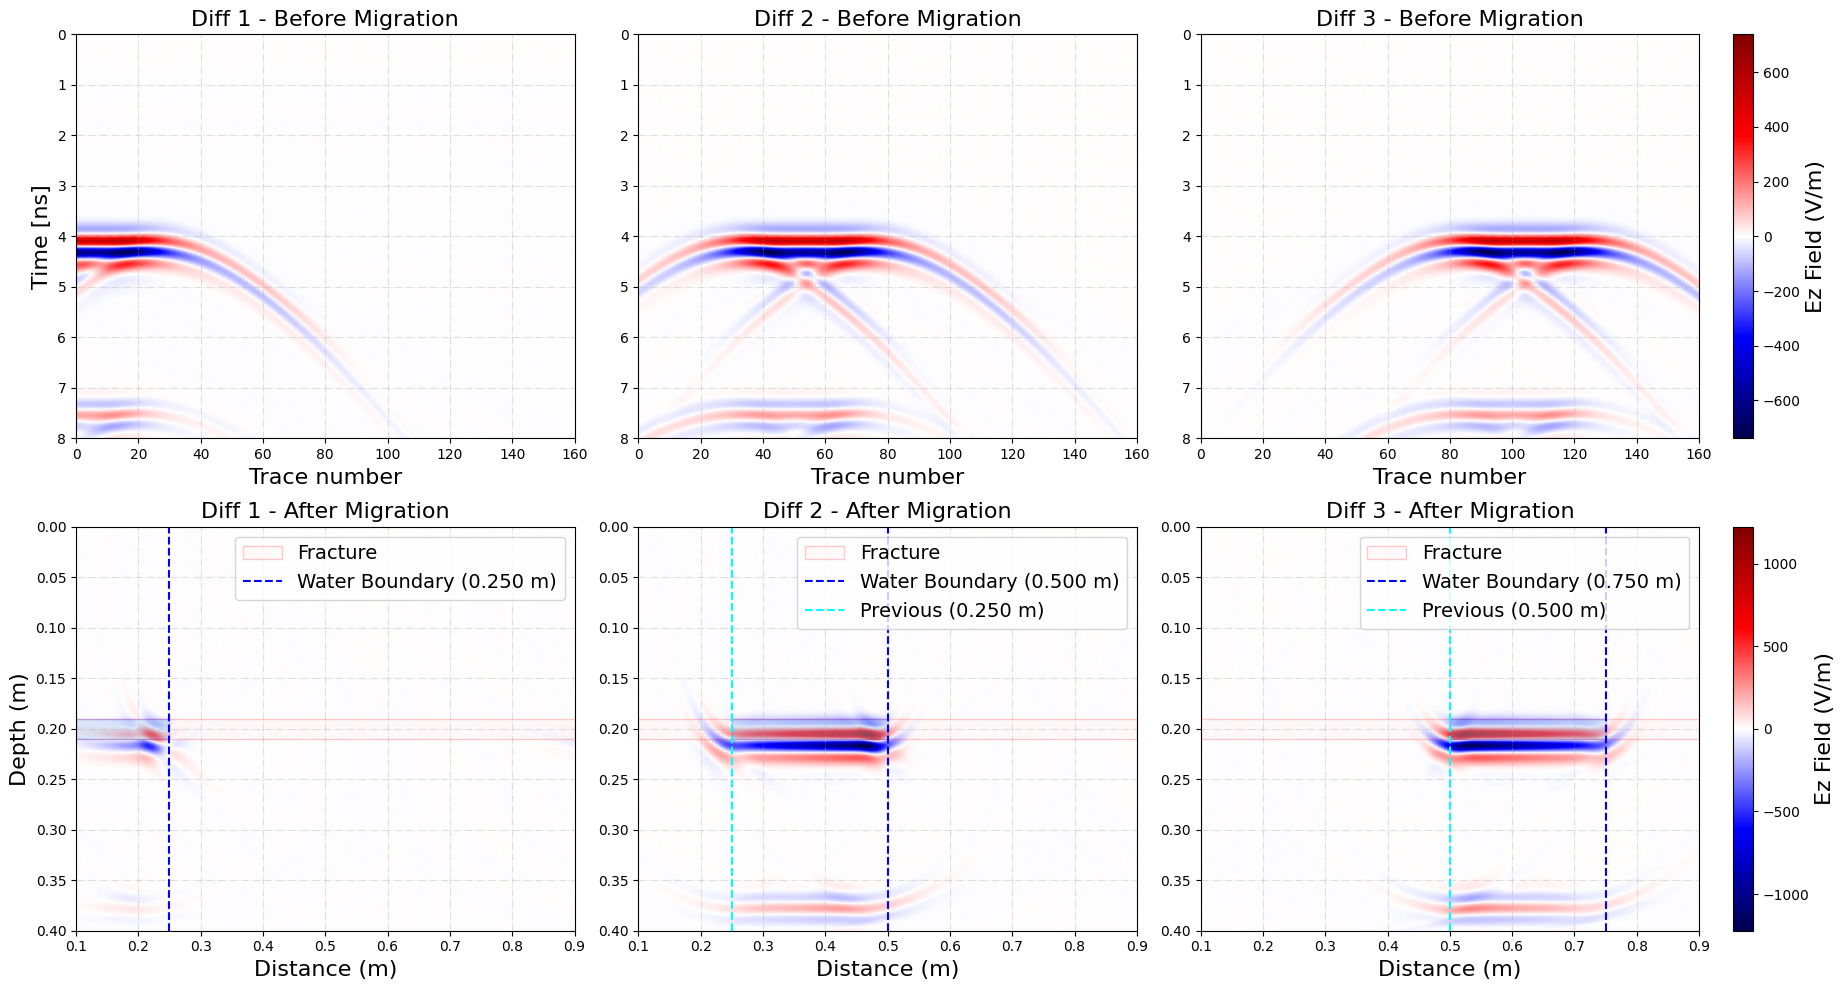

In [80]:
# Plot 2 rows x 3 columns: before and after migration for diff_1, diff_2, diff_3
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Data and water boundaries for each column
data_sets = [
    ('Diff 1', diff_1_degained_Impdar_object, diff_1_phaseshift_migrated, 0.0, 0.250),
    ('Diff 2', diff_2_degained_Impdar_object, diff_2_phaseshift_migrated, 0.250, 0.500),
    ('Diff 3', diff_3_degained_Impdar_object, diff_3_phaseshift_migrated, 0.500, 0.750),
]

x0 = 0.100
x1 = 0.900
depth = 0.4
fracture_y0 = depth - 0.190
fracture_y1 = depth - 0.210

# Compute common color scales per row
before_data_list = [ds[1].data for ds in data_sets]
after_data_list = [ds[2].data for ds in data_sets]

vmin_row0 = -np.amax([np.abs(d).max() for d in before_data_list])
vmax_row0 =  np.amax([np.abs(d).max() for d in before_data_list])

vmin_row1 = -np.amax([np.abs(d).max() for d in after_data_list])
vmax_row1 =  np.amax([np.abs(d).max() for d in after_data_list])

for col, (title, before_data, after_data, water_old, water_new) in enumerate(data_sets):
    # Row 1: Before migration
    im0 = axes[0, col].imshow(before_data.data, cmap='seismic', aspect='auto', extent=extent,
                        vmin=vmin_row0, vmax=vmax_row0)
    axes[0, col].set_title(f'{title} - Before Migration', fontsize=16)
    axes[0, col].set_xlabel('Trace number', fontsize=16)
    if col == 0:
        axes[0, col].set_ylabel('Time [ns]', fontsize=16)
    axes[0, col].grid(which='both', axis='both', linestyle='-.', alpha=0.4)
    
    # Row 2: After migration with overlays
    im1 = axes[1, col].imshow(after_data.data, cmap='seismic', aspect='auto', extent=[x0, x1, depth, 0],
                             vmin=vmin_row1, vmax=vmax_row1)
    axes[1, col].set_title(f'{title} - After Migration', fontsize=16)
    axes[1, col].set_xlabel('Distance (m)', fontsize=16)
    if col == 0:
        axes[1, col].set_ylabel('Depth (m)', fontsize=16)
    
    # Fracture zone
    axes[1, col].add_patch(Rectangle((x0, fracture_y0), x1 - x0, fracture_y1 - fracture_y0,
                                     facecolor='#ffe6e6', edgecolor='red', linewidth=1.0, alpha=0.2,
                                     label='Fracture'))
    
    # Water boundaries (only if they're within the plot range)
    if water_new > x0 and water_new < x1:
        axes[1, col].axvline(x=water_new, color='blue', linestyle='--', linewidth=1.5,
                            label=f'Water Boundary ({water_new:.3f} m)')
    
    if water_old > x0 and water_old < x1 and water_old != 0:
        axes[1, col].axvline(x=water_old, color='cyan', linestyle='--', linewidth=1.5,
                            label=f'Previous ({water_old:.3f} m)')
    
    # Water front (filled portion)
    if water_new > x0:
        fill_start = max(x0, water_old)
        fill_end = min(x1, water_new)
        if fill_start < fill_end:
            axes[1, col].add_patch(Rectangle((fill_start, fracture_y0), fill_end - fill_start, 
                                            fracture_y1 - fracture_y0,
                                            facecolor='#4da3ff', edgecolor='blue', alpha=0.2))
    
    axes[1, col].grid(which='both', axis='both', linestyle='-.', alpha=0.4)
    axes[1, col].legend(loc='upper right', fontsize=14)

# Set consistent y limits
# for ax in axes[0, :]:
#     ax.set_ylim(0, 8)

for ax in axes[1, :]:
    ax.set_ylim(depth, 0)

plt.tight_layout()
# Colorbars for each row
cbar1 = fig.colorbar(im0, ax=axes[0, :], fraction=0.02, pad=0.02)
cbar1.set_label('Ez Field (V/m)', fontsize=16)
cbar2 = fig.colorbar(im1, ax=axes[1, :], fraction=0.02, pad=0.02)
cbar2.set_label('Ez Field (V/m)', fontsize=16)


# save image
path = 'Images_Experiment_9\\Results\\Migrating\\Phaseshift_migrated.png'
plt.savefig(fname = path, bbox_inches='tight')


plt.show()
